# Model LP2

Model LP2 extends [Model LP](GL06LP.ipynb) from Chapter 5 of {cite:t}`GodleyLavoie2006MonetaryEconomicsIntegrated` by making bond prices **endogenous** through a target-proportion mechanism. In Model LP, bond prices are set exogenously. In LP2, the Treasury adjusts bond prices when the share of bonds in household government debt moves outside a target range $[\text{bot}, \text{top}]$. Households form **adaptive expectations** about future bond prices.

## Module Contents

As with all `MacroStat` models, GL06LP2 is divided into Variables, Parameters, Scenarios, and Behavior. The module-level documentation can be found at:

```{eval-rst}
.. toctree::
    :maxdepth: 2

    Variables <GL06LP2/variables.rst>
    Parameters <GL06LP2/parameters.rst>
    Equations <GL06LP2/equations.rst>
    Scenarios <GL06LP2/scenarios.rst>
```

## Key Changes from LP

Model LP2 differs from [Model LP](GL06LP.ipynb) in three respects:

### 1. Endogenous Bond Price (Target-Proportion Mechanism)

The Treasury monitors the proportion of bonds in total household government debt:

```{math}
TP(t) = \frac{BL_h(t-1) \cdot p_{bl}(t-1)}{BL_h(t-1) \cdot p_{bl}(t-1) + B_h(t-1)}
```

When $TP > \text{top}$, the Treasury lets bond prices drift upwards; when $TP < \text{bot}$, prices drift downwards:

```{math}
p_{bl}(t) = \left(1 + z_1 \cdot \beta - z_2 \cdot \beta\right) \cdot p_{bl}(t-1)
```

where $z_1 = \mathbb{1}[TP > \text{top}]$ and $z_2 = \mathbb{1}[TP < \text{bot}]$.

### 2. Adaptive Expectations for Bond Prices

Instead of static expectations ($p_{bl}^e = p_{bl}$), households form adaptive expectations:

```{math}
p_{bl}^e(t) = p_{bl}^e(t-1) - \beta_e \cdot \left(p_{bl}^e(t-1) - p_{bl}(t)\right)
```

### 3. New Parameters

| Parameter | Notation | Default | Description |
|-----------|----------|---------|-------------|
| ExpectationAdjustmentSpeed | $\beta_e$ | 0.5 | Speed of adaptive expectations |
| BondPriceAdjustmentStep | $\beta$ | 0.001 | Bond price adjustment step |
| TargetProportionUpper | $\text{top}$ | 0.52 | Upper band for TP |
| TargetProportionLower | $\text{bot}$ | 0.47 | Lower band for TP |

### Transaction Flow Matrix

```{csv-table} Accounting Transaction Matrix for Model LP2
:file: GL06LP2/transaction_matrix.csv
:header-rows: 2
:stub-columns: 1
```

### Balance Sheet Matrix

```{csv-table} Balance Sheet for Model LP2
:file: GL06LP2/balance_sheet.csv
:header-rows: 2
:stub-columns: 1
```

## Model Dynamics

### Preparatory Steps

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import logging
import sys

from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter

from macrostat.models.GL06LP2 import GL06LP2, ParametersGL06LP2, ScenariosGL06LP2

plt.style.use("../../macrostat.mplstyle")
importlib.reload(logging)
logging.basicConfig(stream=sys.stdout, level=logging.INFO)

### Convergence to the Steady State

In [2]:
params = ParametersGL06LP2()
model = GL06LP2(parameters=params)
model.simulate()
output = model.variables.to_pandas()

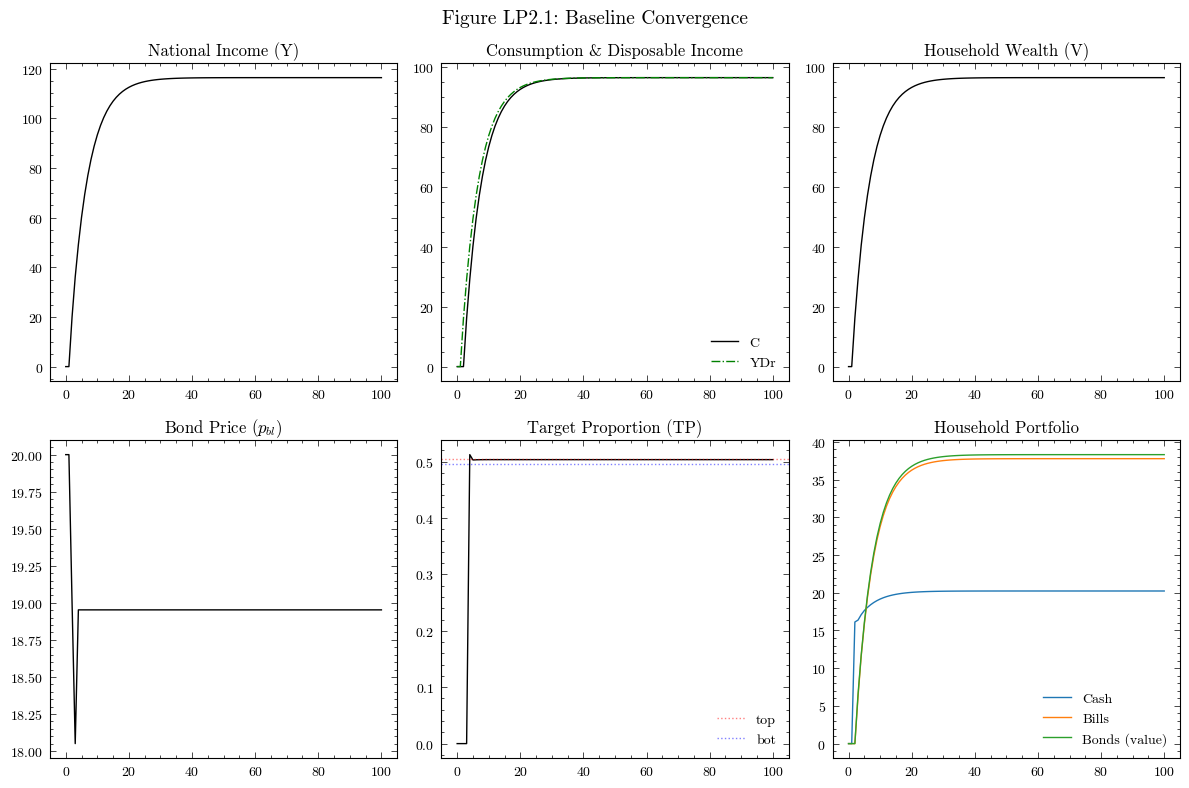

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle("Figure LP2.1: Baseline Convergence", fontsize=14)

axes[0, 0].plot(output.index, output["NationalIncome"], color="k")
axes[0, 0].set_title("National Income (Y)")

axes[0, 1].plot(output.index, output["ConsumptionHousehold"], color="k", label="C")
axes[0, 1].plot(output.index, output["DisposableIncome"], color="g", linestyle="-.", label="YDr")
axes[0, 1].set_title("Consumption & Disposable Income")
axes[0, 1].legend()

axes[0, 2].plot(output.index, output["Wealth"], color="k")
axes[0, 2].set_title("Household Wealth (V)")

axes[1, 0].plot(output.index, output["BondPrice"], color="k")
axes[1, 0].set_title("Bond Price ($p_{bl}$)")

axes[1, 1].plot(output.index, output["TargetProportion"], color="k")
axes[1, 1].axhline(model.parameters["TargetProportionUpper"], color="r", linestyle=":", alpha=0.5, label="top")
axes[1, 1].axhline(model.parameters["TargetProportionLower"], color="b", linestyle=":", alpha=0.5, label="bot")
axes[1, 1].set_title("Target Proportion (TP)")
axes[1, 1].legend()

axes[1, 2].plot(output.index, output["HouseholdCashStock"], label="Cash")
axes[1, 2].plot(output.index, output["HouseholdBillStock"], label="Bills")
axes[1, 2].plot(
    output.index,
    output["HouseholdBondStock"].mul(output[("BondPrice","Macroeconomy")],axis=0),
    label="Bonds (value)",
)
axes[1, 2].set_title("Household Portfolio")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

### Perturbation 1: Rise in the Bill Rate (Section 5.8, first experiment)

Following Section 5.8 of {cite:t}`GodleyLavoie2006MonetaryEconomicsIntegrated`, we increase the interest rate on bills from 3% to 4%, but this time *without* modifying bond yields exogenously (unlike Model LP). The bill rate increase makes bills more attractive, causing households to shift away from bonds. This reduces the target proportion $TP$ below the lower band, inducing the Treasury to let bond prices fall — thus *endogenously* raising the bond yield.

The two stabilizing effects (higher bond yield + reduced expected capital loss as expectations adapt) eventually bring $TP$ back inside the target range.

In [4]:
scenarios = ScenariosGL06LP2(parameters=params)
sc1 = scenarios.get_scenario_index("Scenario.1: Rise in bill rate")
model1 = GL06LP2(parameters=params, scenarios=scenarios)
model1.simulate(scenario=sc1)
output_sc1 = model1.variables.to_pandas()

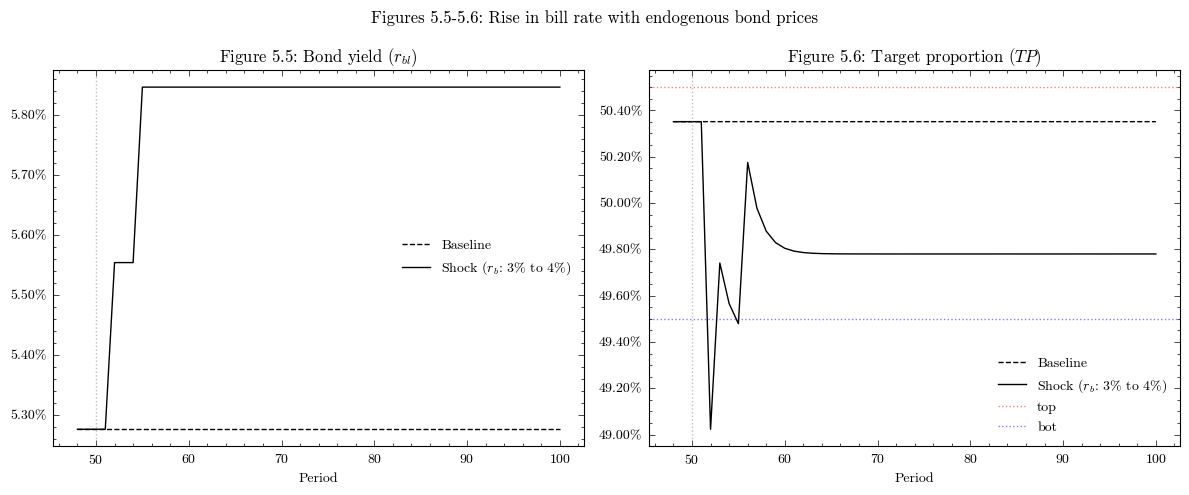

In [5]:
trigger = params["scenario_trigger"]
dfo = output_sc1.loc[trigger - 2:]
dfo_base = output.loc[trigger - 2:]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Figure 5.5: Bond yield
axes[0].plot(dfo_base.index, dfo_base['BondYield'], 'k--', label='Baseline')
axes[0].plot(dfo.index, dfo['BondYield'], 'k-', label='Shock ($r_b$: 3% to 4%)')
axes[0].axvline(x=trigger, color='grey', linestyle=':', alpha=0.5)
axes[0].set_title('Figure 5.5: Bond yield ($r_{bl}$)')
axes[0].set_xlabel('Period')
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].legend(frameon=False)

# Figure 5.6: Target proportion
axes[1].plot(dfo_base.index, dfo_base['TargetProportion'], 'k--', label='Baseline')
axes[1].plot(dfo.index, dfo['TargetProportion'], 'k-', label='Shock ($r_b$: 3% to 4%)')
axes[1].axhline(model.parameters["TargetProportionUpper"], color="r", linestyle=":", alpha=0.5, label="top")
axes[1].axhline(model.parameters["TargetProportionLower"], color="b", linestyle=":", alpha=0.5, label="bot")
axes[1].axvline(x=trigger, color='grey', linestyle=':', alpha=0.5)
axes[1].set_title('Figure 5.6: Target proportion ($TP$)')
axes[1].set_xlabel('Period')
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend(frameon=False)

fig.suptitle('Figures 5.5-5.6: Rise in bill rate with endogenous bond prices')
plt.tight_layout()
plt.show()

### Perturbation 2: Anticipated Fall in Bond Prices (Section 5.8, second experiment)

In this experiment, household portfolio holders expect a fall in the price of bonds. The expected bond price drops by 1 unit. This implies a lower expected rate of return on bonds ($ERr_{bl} < r_{bl}$), causing households to demand fewer bonds and more bills and cash.

If the change is large enough, the proportion $TP$ falls below the lower band, inducing the Treasury to reduce bond prices. The reduction in actual bond prices has two stabilizing effects:
1. The bond yield $r_{bl}$ rises (higher coupon relative to price).
2. As expectations adapt gradually, the expected capital loss diminishes.

This shows how market expectations can influence realized financial outcomes when the monetary authorities are swayed by market pressures.

In [6]:
sc2 = scenarios.get_scenario_index("Scenario.2: Expected bond price fall")
model2 = GL06LP2(parameters=params, scenarios=scenarios)
model2.simulate(scenario=sc2)
output_sc2 = model2.variables.to_pandas()

/tmp/ipykernel_17700/3454129722.py:35: UserWarning: Glyph 8211 (\N{EN DASH}) missing from font(s) cmr10.
  plt.tight_layout()
/home/karl/anaconda3/envs/mstest/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8211 (\N{EN DASH}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


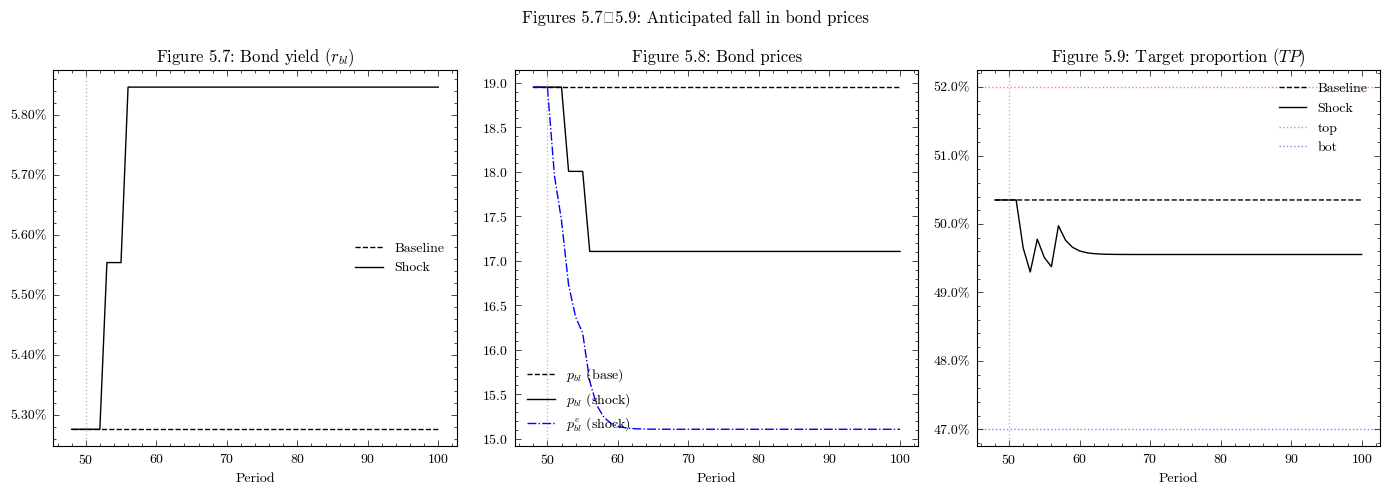

In [7]:
dfo2 = output_sc2.loc[trigger - 2:]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Figure 5.7: Bond yield
axes[0].plot(dfo_base.index, dfo_base['BondYield'], 'k--', label='Baseline')
axes[0].plot(dfo2.index, dfo2['BondYield'], 'k-', label='Shock')
axes[0].axvline(x=trigger, color='grey', linestyle=':', alpha=0.5)
axes[0].set_title('Figure 5.7: Bond yield ($r_{bl}$)')
axes[0].set_xlabel('Period')
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].legend(frameon=False)

# Figure 5.8: Expected and actual bond prices
axes[1].plot(dfo_base.index, dfo_base['BondPrice'], 'k--', label='$p_{bl}$ (base)')
axes[1].plot(dfo2.index, dfo2['BondPrice'], 'k-', label='$p_{bl}$ (shock)')
axes[1].plot(dfo2.index, dfo2['ExpectedBondPrice'], 'b-.', label='$p_{bl}^e$ (shock)')
axes[1].axvline(x=trigger, color='grey', linestyle=':', alpha=0.5)
axes[1].set_title('Figure 5.8: Bond prices')
axes[1].set_xlabel('Period')
axes[1].legend(frameon=False)

# Figure 5.9: Target proportion
axes[2].plot(dfo_base.index, dfo_base['TargetProportion'], 'k--', label='Baseline')
axes[2].plot(dfo2.index, dfo2['TargetProportion'], 'k-', label='Shock')
axes[2].axhline(0.52, color='r', linestyle=':', alpha=0.5, label='top')
axes[2].axhline(0.47, color='b', linestyle=':', alpha=0.5, label='bot')
axes[2].axvline(x=trigger, color='grey', linestyle=':', alpha=0.5)
axes[2].set_title('Figure 5.9: Target proportion ($TP$)')
axes[2].set_xlabel('Period')
axes[2].yaxis.set_major_formatter(PercentFormatter(1))
axes[2].legend(frameon=False)

fig.suptitle('Figures 5.7–5.9: Anticipated fall in bond prices')
plt.tight_layout()
plt.show()

In [8]:
# End of LP2 notebook